⚽ Analyse de la Premier League (Saison 2021-2022)

1. Introduction

Ce projet analyse les performances des équipes à domicile et à l'extérieur pour identifier les facteurs de succès.

In [54]:
import pandas as pd
df = pd.read_csv('E0.csv')
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,1.62,0.50,1.75,2.05,1.81,2.13,2.05,2.17,1.80,2.09
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,2.25,-1.00,2.05,1.75,2.17,1.77,2.19,1.93,2.10,1.79
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,1.62,0.25,1.79,2.15,1.81,2.14,1.82,2.19,1.79,2.12
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,1.94,-1.50,2.05,1.75,2.12,1.81,2.16,1.93,2.06,1.82
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,1.67,-0.50,2.05,1.88,2.05,1.88,2.08,1.90,2.03,1.86


In [55]:
df_clean = df[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR']].copy()
df_clean.columns = ['Date','Domicile','Exterieur','Buts_Dom','Buts_Ext','Resultat']
df_clean.head()

,Date,Domicile,Exterieur,Buts_Dom,Buts_Ext,Resultat
0,13/08/2021,Brentford,Arsenal,2,0,H
1,14/08/2021,Man United,Leeds,5,1,H
2,14/08/2021,Burnley,Brighton,1,2,A
3,14/08/2021,Chelsea,Crystal Palace,3,0,H
4,14/08/2021,Everton,Southampton,3,1,H


In [ ]:
import matplotlib.pyplot as plt
top_attaques = df_clean.groupby('Domicile')['Buts_Dom'].mean().sort_values(ascending=False)
print("Moyenne de buts marqués à domicile par match :")
print(top_attaques.head(5))

Moyenne de buts marqués à domicile par match :
Domicile
Man City     3.052632
Liverpool    2.578947
Tottenham    2.000000
Chelsea      1.947368
Arsenal      1.842105
Name: Buts_Dom, dtype: float64


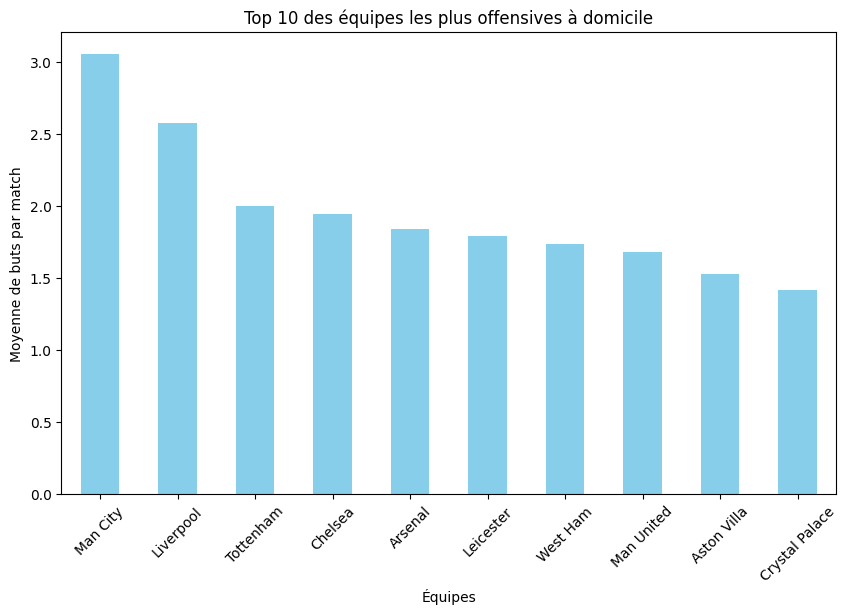

In [57]:
plt.figure(figsize=(10,6))
top_attaques.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 des équipes les plus offensives à domicile')
plt.ylabel('Moyenne de buts par match')
plt.xlabel('Équipes')
plt.xticks(rotation=45)
plt.show()

Statistiques des résultats de la saison :
- Victoires à domicile (H) : 42.9%
- Victoires à l'extérieur (A) : 33.9%
- Matchs nuls (D) : 23.2%


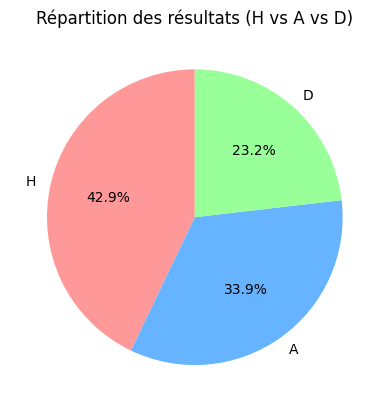

In [58]:

stats_resultat = df_clean['Resultat'].value_counts(normalize=True)*100
print("Statistiques des résultats de la saison :")
print(f"- Victoires à domicile (H) : {stats_resultat['H']:.1f}%")
print(f"- Victoires à l'extérieur (A) : {stats_resultat['A']:.1f}%")
print(f"- Matchs nuls (D) : {stats_resultat['D']:.1f}%")
stats_resultat.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title("Répartition des résultats (H vs A vs D)")
plt.ylabel('')
plt.show()

2.Analyse des résultats

Avantage Domicile : On constate que 43% des matchs se terminent par une victoire à domicile.

In [59]:

def calculer_points_Dom(resultat):
    if resultat == 'H':
        return 3
    elif resultat == 'D':
        return 1
    else:
        return 0
df_clean['Points_Dom'] = df_clean['Resultat'].apply(calculer_points_Dom)


df_clean[['Domicile', 'Exterieur', 'Resultat', 'Points_Dom']].head()

,Domicile,Exterieur,Resultat,Points_Dom
0,Brentford,Arsenal,H,3
1,Man United,Leeds,H,3
2,Burnley,Brighton,A,0
3,Chelsea,Crystal Palace,H,3
4,Everton,Southampton,H,3


In [60]:

forteresses = df_clean.groupby('Domicile').agg({
    'Points_Dom': 'sum',
    'Resultat': 'count' 
}).rename(columns={'Resultat': 'Matchs_Joues'})


forteresses = forteresses.sort_values(by='Points_Dom', ascending=False)

print("Classement des équipes à domicile :")
print(forteresses)

Classement des équipes à domicile :
                Points_Dom  Matchs_Joues
Domicile                                
Liverpool               49            19
Man City                47            19
Arsenal                 41            19
Tottenham               40            19
Man United              35            19
Chelsea                 34            19
Leicester               34            19
West Ham                32            19
Newcastle               30            19
Everton                 29            19
Crystal Palace          29            19
Southampton             25            19
Brentford               24            19
Wolves                  24            19
Aston Villa             23            19
Brighton                22            19
Burnley                 21            19
Leeds                   18            19
Norwich                 12            19
Watford                  8            19


In [61]:
def calculer_points_Ext(resultat):
    if resultat == 'A':
        return 3
    elif resultat == 'D':
        return 1
    else:
        return 0


df_clean['Points_Ext'] = df_clean['Resultat'].apply(calculer_points_Ext)
df_clean[['Domicile', 'Exterieur', 'Resultat', 'Points_Ext']].head()

,Domicile,Exterieur,Resultat,Points_Ext
0,Brentford,Arsenal,H,0
1,Man United,Leeds,H,0
2,Burnley,Brighton,A,3
3,Chelsea,Crystal Palace,H,0
4,Everton,Southampton,H,0


In [62]:
pts_dom = df_clean.groupby('Domicile')['Points_Dom'].sum()
pts_ext = df_clean.groupby('Exterieur')['Points_Ext'].sum()


comparatif = pd.DataFrame({
    'Points_Domicile': pts_dom,
    'Points_Exterieur': pts_ext
})


comparatif['Total_Points'] = comparatif['Points_Domicile'] + comparatif['Points_Exterieur']


comparatif = comparatif.sort_values(by='Total_Points', ascending=False)
display(comparatif.head(10))

,Points_Domicile,Points_Exterieur,Total_Points
Man City,47,46,93
Liverpool,49,43,92
Chelsea,34,40,74
Tottenham,40,31,71
Arsenal,41,28,69
Man United,35,23,58
West Ham,32,24,56
Leicester,34,18,52
Brighton,22,29,51
Wolves,24,27,51


In [63]:

buts_marques_dom = df_clean.groupby('Domicile')['Buts_Dom'].sum()

buts_marques_ext = df_clean.groupby('Exterieur')['Buts_Ext'].sum()


attaque = (buts_marques_dom + buts_marques_ext).sort_values(ascending=False)

print("Top 5 des meilleures attaques :")
print(attaque.head(5))

Top 5 des meilleures attaques :
Domicile
Man City     99
Liverpool    94
Chelsea      76
Tottenham    69
Leicester    62
dtype: int64


In [64]:

buts_encaisses_dom = df_clean.groupby('Domicile')['Buts_Ext'].sum()


buts_encaisses_ext = df_clean.groupby('Exterieur')['Buts_Dom'].sum()


defense = (buts_encaisses_dom + buts_encaisses_ext).sort_values(ascending=True) 

print("\nTop 5 des meilleures défenses (ceux qui encaissent le moins) :")
print(defense.head(5))


Top 5 des meilleures défenses (ceux qui encaissent le moins) :
Domicile
Liverpool    26
Man City     26
Chelsea      33
Tottenham    40
Wolves       43
dtype: int64


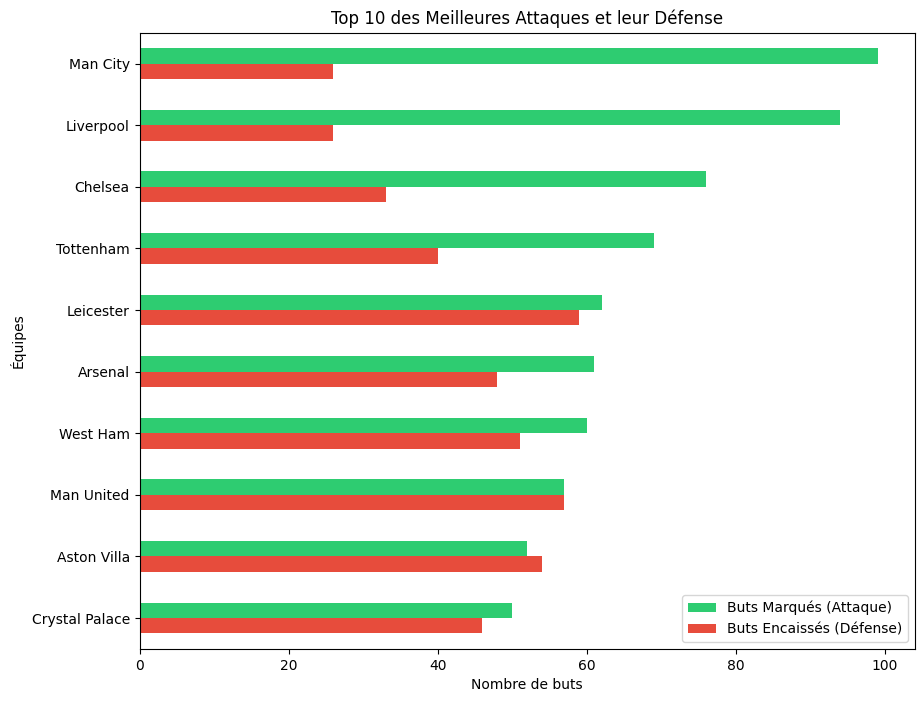

In [65]:

bilan_complet = pd.DataFrame({
    'Buts_Marqués': attaque,
    'Buts_Encaissés': defense
})

bilan_complet = bilan_complet.sort_values(by='Buts_Marqués', ascending=False)

bilan_complet.head(10).plot(kind='barh', figsize=(10,8), color=['#2ecc71', '#e74c3c'])

plt.title('Top 10 des Meilleures Attaques et leur Défense')
plt.xlabel('Nombre de buts')
plt.ylabel('Équipes')
plt.legend(['Buts Marqués (Attaque)', 'Buts Encaissés (Défense)'])
plt.gca().invert_yaxis() 
plt.show()

Meilleure Attaque : L'équipe de Manchester City domine le championnat avec une moyenne de buts impressionnante.

Meilleure Défense : L'équipe de Manchester City et Liverpool ex aequo posséde la meilleurs des défenses.

Terminé ! Les fichiers 'classement_final_complet.csv' et 'top_10_performances.png' sont dans ton dossier.


<Figure size 1200x800 with 0 Axes>

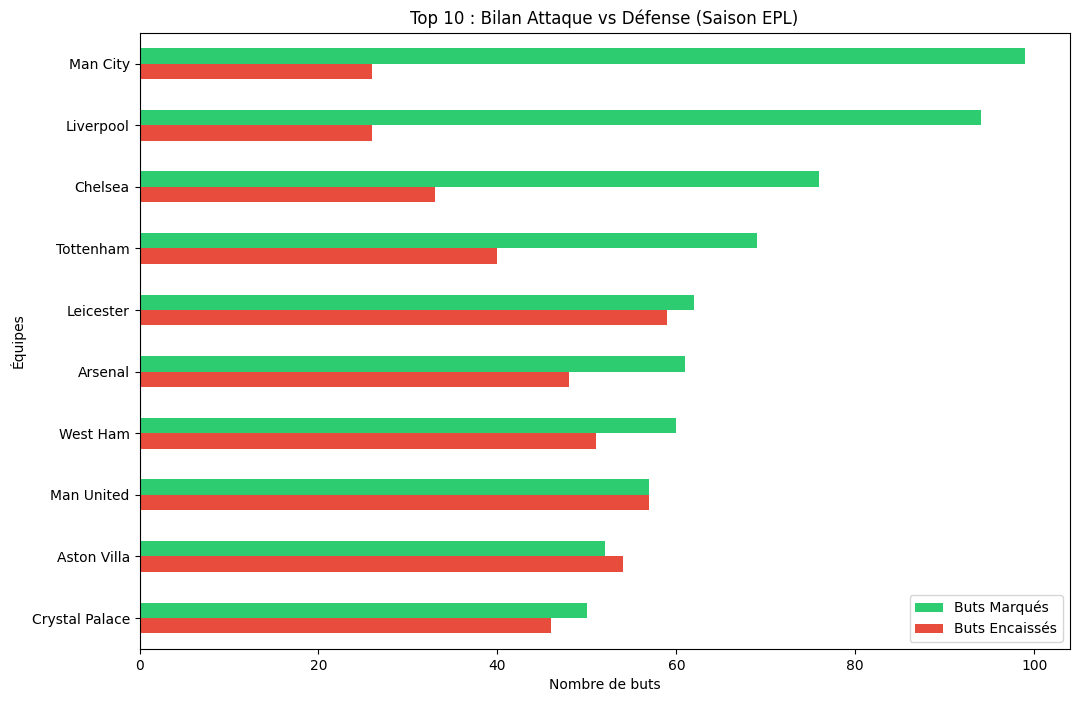

In [66]:

bilan_complet.to_csv('classement_final_complet.csv', index=True)

plt.figure(figsize=(12,8))


bilan_complet.head(10).plot(kind='barh', color=['#2ecc71', '#e74c3c'], figsize=(12,8))

plt.title('Top 10 : Bilan Attaque vs Défense (Saison EPL)')
plt.xlabel('Nombre de buts')
plt.ylabel('Équipes')
plt.legend(['Buts Marqués', 'Buts Encaissés'])
plt.gca().invert_yaxis() 


plt.savefig('top_10_performances.png', dpi=300, bbox_inches='tight')

print("Terminé ! Les fichiers 'classement_final_complet.csv' et 'top_10_performances.png' sont dans ton dossier.")